# Example 8b — MNIST-CP target-conditioned Wasserstein score fields

This notebook replaces the label-only MNIST-CP score model from Example 8 with a target-shape-conditioned model.  The learned field is

\[
S_	heta(	ilde x_i, 	ilde X, 	au, z), \qquad z=f_\phi(X_{
m target}),
\]

so the score for particle `i` receives the individual current location, the full current empirical measure, the diffusion time, and a latent code for the target contour.  This keeps the experiment close to the finite-particle Wasserstein h-transform picture, where the drift is `2 D log u`, while borrowing the ShapeGF idea of shape latents and multi-scale denoising.

The notebook has two stages:

1. Train a target-conditioned score autoencoder/reconstructor.
2. Fit a latent prior over encoded target shapes, then generate new contours by sampling a latent and running the same target-conditioned dynamics.


## Imports

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(torch.cuda.get_device_properties(0))

CUDA available: True
GPU: NVIDIA H100 80GB HBM3
_CudaDeviceProperties(name='NVIDIA H100 80GB HBM3', major=9, minor=0, total_memory=81079MB, multi_processor_count=132)


In [2]:
from __future__ import annotations

from pathlib import Path
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mnist.conditioned_diffusion import GeneratedPointCloudSet
from mnist.mnist_cp import (
    load_mnist_cp_splits,
    pairwise_chamfer_distance_matrix,
    one_nn_leave_one_out_chamfer,
    coverage_unique_argmin_chamfer,
    unit_square_to_mnist_cp_points,
)
from mnist.target_conditioned_score import (
    LatentCritic,
    LatentGenerator,
    TargetConditionedScoreModel,
    load_target_conditioned_experiment_checkpoint,
    encode_target_latents,
    evaluate_hybrid_oracle_neural_reconstruction,
    evaluate_latent_sensitivity,
    evaluate_model_vs_mixture_oracle,
    evaluate_target_conditioned_score_model,
    fit_score_calibration_against_mixture_oracle,
    fit_gaussian_latent_prior,
    fit_pca_gmm_latent_prior,
    fit_pca_latent_prior,
    make_sigma_tau_schedule,
    paired_chamfer_reconstruction_metrics,
    latent_nearest_neighbor_diagnostics,
    latent_nearest_neighbor_summary,
    layernorm_project_latents,
    perturb_target_conditioned_positions,
    reconstruct_target_conditioned_point_clouds,
    reconstruct_target_conditioned_from_latents,
    sample_oracle_mixture_annealed_dynamics,
    sample_gaussian_latent_prior,
    sample_empirical_latent_prior,
    sample_pca_gmm_latent_prior,
    sample_pca_latent_prior,
    sample_target_conditioned_annealed_dynamics,
    save_target_conditioned_experiment_checkpoint,
    sample_wgan_latent_prior,
    train_latent_wgan_gp,
    train_latent_only_student_from_teacher,
    train_target_conditioned_score_model,
)

SEED = 1234
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("repo root:", REPO_ROOT)
print("device:", DEVICE)


repo root: /workspace/condition_df
device: cuda


In [3]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)


## Configuration

The default full setting uses all 800 MNIST-CP contour points and a ShapeGF-style geometric noise schedule, converted to the finite-particle `tau` variable by

\[
	au = 

rac{\sigma_{[0,1]}^2}{2K}.
\]

For a quick CPU smoke run, set `FAST_DEMO = True`.

In [4]:
FAST_DEMO = False

MNIST_CP_PATH = REPO_ROOT / "mnist_data" / "mnist_cp.npz"

# Score-autoencoder checkpointing.
# "auto": load the checkpoint if it exists, otherwise train and save it.
# "load": require an existing checkpoint and skip score training.
# "train": ignore any existing checkpoint and retrain.
CHECKPOINT_MODE = "auto"
SAVE_SCORE_CHECKPOINT = True
CHECKPOINT_DIR = REPO_ROOT / "artifacts" / "checkpoints"
EXPERIMENT8B_CHECKPOINT_PATH = CHECKPOINT_DIR / "example_8b_mnist_cp_target_conditioned_score.pt"

if FAST_DEMO:
    TRAIN_PER_CLASS = 128
    VAL_PER_CLASS = 32
    TEST_PER_CLASS = 32
    POINTS_PER_CLOUD = 256

    SCORE_EPOCHS = 12
    SCORE_BATCH_SIZE = 16
    RECONSTRUCTION_COUNT = 20
    SYNTHETIC_PER_CLASS = 4

    Z_DIM = 64
    TARGET_ENCODER_HIDDEN_DIM = 128
    SCORE_GRID_SIZE = 32
    SCORE_BASE_CHANNELS = 24
    SCORE_GRID_FEATURE_DIM = 48
    SET_FEATURE_DIM = 64
    SET_HIDDEN_DIM = 64
    SCORE_HIDDEN_DIM = 128

    SIGMA_MAX = 0.20
    SIGMA_MIN = 0.01
    NUM_SIGMA_LEVELS = 6
    STEPS_PER_LEVEL = 4

    SCORE_CALIBRATION_MAX_SAMPLES = 24
    HYBRID_BISECTION_MAX_SAMPLES = 8
    LATENT_PRIOR_DIAGNOSTIC_PER_CLASS = 4
    LATENT_WGAN_EPOCHS = 20
else:
    TRAIN_PER_CLASS = 2000
    VAL_PER_CLASS = 250
    TEST_PER_CLASS = 250
    POINTS_PER_CLOUD = None  # all saved MNIST-CP points, usually 800

    # The loss in previous runs plateaued early; longer training did not fix sampler collapse.
    # Use early stopping and focus on training states that the sampler actually visits.
    SCORE_EPOCHS = 80
    SCORE_BATCH_SIZE = 32
    RECONSTRUCTION_COUNT = 64
    SYNTHETIC_PER_CLASS = 64

    Z_DIM = 128
    TARGET_ENCODER_HIDDEN_DIM = 256
    SCORE_GRID_SIZE = 64
    SCORE_BASE_CHANNELS = 48
    SCORE_GRID_FEATURE_DIM = 96
    SET_FEATURE_DIM = 128
    SET_HIDDEN_DIM = 128
    SCORE_HIDDEN_DIM = 256

    # Start with a milder largest scale. After real-z reconstruction works, try SIGMA_MAX=0.50.
    SIGMA_MAX = 0.25
    SIGMA_MIN = 0.005
    NUM_SIGMA_LEVELS = 10
    STEPS_PER_LEVEL = 10

    SCORE_CALIBRATION_MAX_SAMPLES = 128
    HYBRID_BISECTION_MAX_SAMPLES = 24
    LATENT_PRIOR_DIAGNOSTIC_PER_CLASS = 16
    LATENT_WGAN_EPOCHS = 1000

SCORE_LR = 1e-3
ENCODER_LR = 1e-3
WEIGHT_DECAY = 1e-4
DSM_PROJECTION = "none"  # Euclidean-cover noising target.
STATE_PROJECTION = "none"  # Do not clip dynamics; clip only for rasterization/plots if needed.
TIME_WEIGHTING = "none"  # scaled target is -eps, so extra tau weighting is unnecessary.

# ShapeGF-style annealed sampler: noise step, then physical-score gradient step.
SAMPLER_SCHEME = "shape_gf_langevin"  # compare with "theory_euler" and "bridge" as ablations.
LANGEVIN_ALPHA = 5e-5
DIFFUSION_TEMPERATURE = 1.0
SCORE_SCALE = 1.0
FINAL_POLISH_STEPS = 0

# Mixed objective: paired DSM + direct mixture queries + oracle trajectory replay.
# Replay distills the exact empirical-mixture field on states that the successful oracle sampler visits.
DIRECT_MIXTURE_PROBABILITY = 0.25
ORACLE_REPLAY_PROBABILITY = 0.50
ORACLE_REPLAY_WEIGHT = 2.0
ORACLE_REPLAY_STEPS_PER_LEVEL = 2
ORACLE_REPLAY_MAX_LEVELS = None
DIRECT_QUERY_MODES = ("noised_target", "uniform", "center_gaussian")
ORACLE_REPLAY_INITIAL_MODES = ("uniform", "center_gaussian", "fixed_center")
DIRECT_QUERY_CENTER_STD = 0.35
MIXTURE_CHUNK_SIZE = 256
MIXTURE_TARGET_NORM_CLIP = None

# The target code z is a global latent vector, optionally augmented by a target raster feature field.
# Target-grid dropout is a training-time knob: if latent-only reconstruction is weak, set this to 0.25--0.50
# and retrain so the global latent path cannot be ignored.
USE_TARGET_GRID_CONDITIONING = True
TARGET_GRID_FEATURE_DIM = SCORE_GRID_FEATURE_DIM
TARGET_GRID_DROPOUT_PROBABILITY = 0.25

# Pointwise field leads; measure-aware branch is a capped, learned gated residual correction.
USE_MEASURE_RESIDUAL = True
MEASURE_GATE_INIT = -5.0
MEASURE_GATE_MAX = 0.10
MEASURE_GATE_REGULARIZATION = 1e-2
FREEZE_MEASURE_BRANCH_EPOCHS = 20

# Per-sigma calibration/clipping against the empirical-mixture oracle.
USE_SCORE_CALIBRATION = True
USE_SCORE_CLIPPING = True
SCORE_CALIBRATION_QUERY_MODES = ("uniform", "center_gaussian", "noised_target")
SCORE_CALIBRATION_CLIP_QUANTILE = 0.99

# Hybrid bisection: oracle for first m sigma levels, then neural. This localizes where collapse begins.
RUN_HYBRID_BISECTION_DIAGNOSTIC = True
HYBRID_PREFIX_LEVELS = (0, 1, 2, 3, 5, NUM_SIGMA_LEVELS)
HYBRID_SUFFIX_LEVELS = ()

EARLY_STOPPING_PATIENCE = 20
LR_SCHEDULER_PATIENCE = 10
LR_SCHEDULER_FACTOR = 0.5
MIN_LR = 1e-5

# Latent-prior diagnostics.  A raw diagonal Gaussian is usually too diffuse; keep it as a baseline,
# then compare empirical-z, empirical-z+small-noise, PCA-shrink, and PCA-GMM priors.
RUN_LATENT_ONLY_RECONSTRUCTION = True
RUN_EMPIRICAL_LATENT_PRIOR = True
RUN_PCA_LATENT_PRIORS = True
RUN_LATENT_WGAN = False

# Latent-only student.  The target-grid teacher now reconstructs well; this
# student distills that field into a model that can be called with z only.
RUN_LATENT_ONLY_STUDENT = True
STUDENT_EPOCHS = 3 if FAST_DEMO else 40
STUDENT_LR = 1e-3
STUDENT_WEIGHT_DECAY = 1e-4
STUDENT_RASTER_LOSS_WEIGHT = 1.0
STUDENT_QUERY_MODES = ("uniform", "center_gaussian", "noised_target")
STUDENT_USE_TARGET_GRID_CONDITIONING = True
STUDENT_USE_LATENT_RASTER_DECODER = True
STUDENT_TARGET_GRID_DROPOUT_PROBABILITY = 0.0
STUDENT_USE_MEASURE_RESIDUAL = USE_MEASURE_RESIDUAL
STUDENT_MEASURE_GATE_INIT = MEASURE_GATE_INIT
STUDENT_MEASURE_GATE_MAX = MEASURE_GATE_MAX
GAUSSIAN_LATENT_DIAGONAL = True
GAUSSIAN_LATENT_COVARIANCE_SCALE = 0.25
GAUSSIAN_LATENT_LAYERNORM_PROJECT = True
EMPIRICAL_LATENT_NOISE_SCALES = (0.0, 0.01, 0.03, 0.05)
EMPIRICAL_LATENT_LAYERNORM_PROJECT = False
PCA_LATENT_DIM = min(32, Z_DIM)
PCA_LATENT_SHRINK = 0.50
PCA_LATENT_LAYERNORM_PROJECT = True
PCA_GMM_COMPONENTS_PER_CLASS = 2 if FAST_DEMO else 8
PCA_GMM_COVARIANCE_SHRINK = 0.50
PCA_GMM_LAYERNORM_PROJECT = True
LATENT_NN_DIAGNOSTIC_MAX_SAMPLES = 256
LATENT_NOISE_DIM = 128
LATENT_WGAN_BATCH_SIZE = 128
LATENT_WGAN_LR = 1e-4
LATENT_WGAN_CRITIC_STEPS = 5
LATENT_WGAN_GP = 10.0

print("FAST_DEMO =", FAST_DEMO)
print("MNIST-CP path =", MNIST_CP_PATH)
print("train/val/test per class =", (TRAIN_PER_CLASS, VAL_PER_CLASS, TEST_PER_CLASS))
print("points per contour =", POINTS_PER_CLOUD if POINTS_PER_CLOUD is not None else "all saved points")
print("score epochs/batch =", (SCORE_EPOCHS, SCORE_BATCH_SIZE))
print("sigma range =", (SIGMA_MAX, SIGMA_MIN), "levels =", NUM_SIGMA_LEVELS)
print("sampler =", SAMPLER_SCHEME, "steps per level =", STEPS_PER_LEVEL)
print("direct/replay probabilities =", (DIRECT_MIXTURE_PROBABILITY, ORACLE_REPLAY_PROBABILITY))
print("target-grid dropout =", TARGET_GRID_DROPOUT_PROBABILITY)
print("latent priors: Gaussian covariance scale =", GAUSSIAN_LATENT_COVARIANCE_SCALE, "PCA dim =", PCA_LATENT_DIM)
print("latent-only student enabled =", RUN_LATENT_ONLY_STUDENT)

print("checkpoint mode/path =", CHECKPOINT_MODE, EXPERIMENT8B_CHECKPOINT_PATH)


FAST_DEMO = False
MNIST-CP path = /workspace/condition_df/mnist_data/mnist_cp.npz
train/val/test per class = (2000, 250, 250)
points per contour = all saved points
score epochs/batch = (80, 32)
sigma range = (0.25, 0.005) levels = 10
sampler = shape_gf_langevin steps per level = 10
direct/replay probabilities = (0.25, 0.5)
target-grid dropout = 0.25
latent priors: Gaussian covariance scale = 0.25 PCA dim = 32
latent-only student enabled = True
checkpoint mode/path = auto /workspace/condition_df/artifacts/checkpoints/example_8b_mnist_cp_target_conditioned_score.pt


## Load MNIST-CP

In [5]:
splits = load_mnist_cp_splits(
    MNIST_CP_PATH,
    train_per_class=TRAIN_PER_CLASS,
    val_per_class=VAL_PER_CLASS,
    test_per_class=TEST_PER_CLASS,
    num_points=POINTS_PER_CLOUD,
    seed=SEED,
    load_images=True,
)
train_pc = splits.train
val_pc = splits.val
reference_pc = splits.test
K = int(train_pc.positions.shape[1])
print("normalization in file:", splits.normalization)
print("train positions:", train_pc.positions.shape, "labels:", np.bincount(train_pc.labels, minlength=10))
print("val positions:", val_pc.positions.shape, "labels:", np.bincount(val_pc.labels, minlength=10))
print("reference positions:", reference_pc.positions.shape, "labels:", np.bincount(reference_pc.labels, minlength=10))
print("K =", K)


normalization in file: bbox_centered_longest_side_to_[-1,1]
train positions: (20000, 800, 2) labels: [2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]
val positions: (2500, 800, 2) labels: [250 250 250 250 250 250 250 250 250 250]
reference positions: (2500, 800, 2) labels: [250 250 250 250 250 250 250 250 250 250]
K = 800


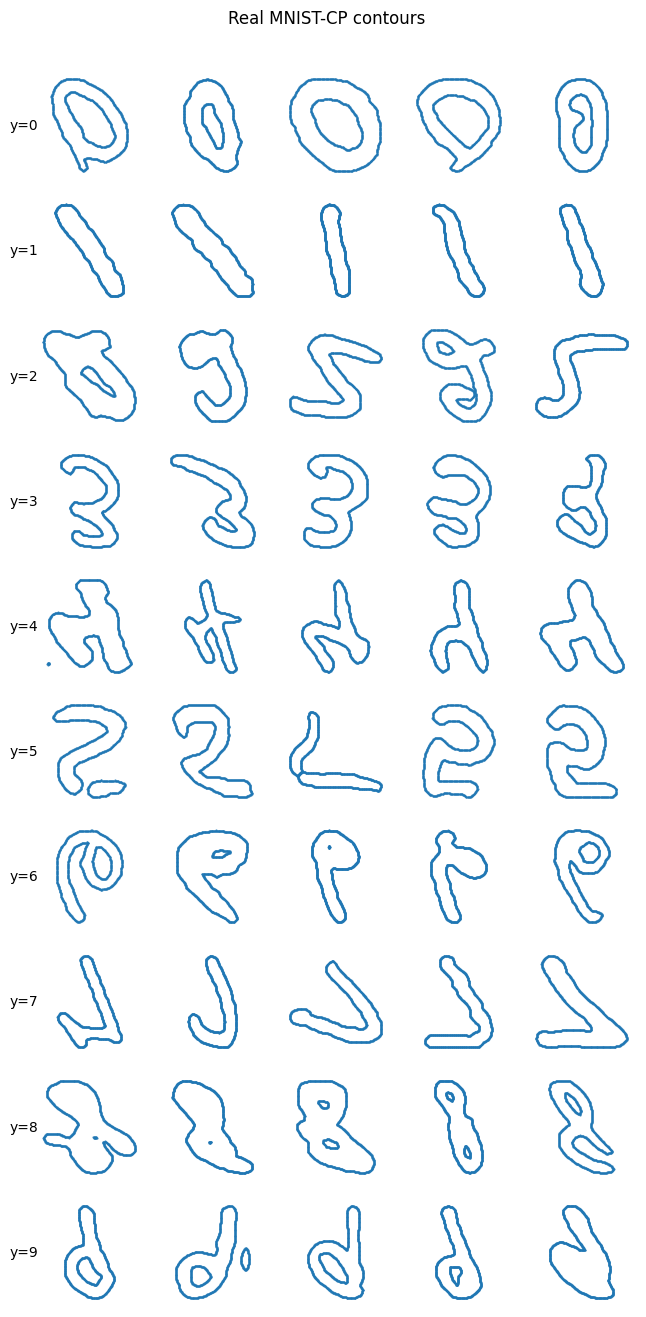

In [6]:
def plot_mnist_cp_gallery(
    positions: np.ndarray,
    labels: np.ndarray,
    *,
    examples_per_label: int = 4,
    title: str | None = None,
    seed: int = 0,
    point_size: float | None = None,
) -> None:
    rng = np.random.default_rng(seed)
    labels_arr = np.asarray(labels, dtype=np.int64)
    unique_labels = np.unique(labels_arr)
    rows = len(unique_labels)
    cols = int(examples_per_label)
    fig, axes = plt.subplots(rows, cols, figsize=(1.3 * cols, 1.3 * rows), squeeze=False)
    for row, label in enumerate(unique_labels):
        idx = np.flatnonzero(labels_arr == label)
        chosen = rng.choice(idx, size=min(cols, len(idx)), replace=False)
        for col in range(cols):
            ax = axes[row, col]
            ax.axis("off")
            ax.set_aspect("equal")
            ax.set_xlim(-0.10, 1.10)
            ax.set_ylim(1.10, -0.10)
            if col < len(chosen):
                pts = positions[chosen[col]]
                size = point_size if point_size is not None else (0.35 if pts.shape[0] > 300 else 1.0)
                ax.scatter(pts[:, 0], pts[:, 1], s=size, alpha=0.80)
            if col == 0:
                ax.text(-0.22, 0.5, f"y={int(label)}", transform=ax.transAxes, va="center")
    if title is not None:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()


plot_mnist_cp_gallery(train_pc.positions, train_pc.labels, examples_per_label=5, title="Real MNIST-CP contours")


## Multi-scale tau schedule

In [7]:
sigma_levels, tau_levels = make_sigma_tau_schedule(
    num_points=K,
    num_levels=NUM_SIGMA_LEVELS,
    sigma_max=SIGMA_MAX,
    sigma_min=SIGMA_MIN,
)
schedule_df = pd.DataFrame(
    {
        "level": np.arange(len(sigma_levels)),
        "sigma_unit_square": sigma_levels,
        "sigma_pixels": 28.0 * sigma_levels,
        "tau": tau_levels,
    }
)
TAU_MIN = float(np.min(tau_levels))
TAU_MAX = float(np.max(tau_levels))
print("tau range:", (TAU_MIN, TAU_MAX))
schedule_df


tau range: (1.5625e-08, 3.90625e-05)


,level,sigma_unit_square,sigma_pixels,tau
0,0,0.250000,7.000000,3.906250e-05
1,1,0.161870,4.532352,1.637613e-05
2,2,0.104807,2.934602,6.865343e-06
3,3,0.067860,1.900092,2.878150e-06
4,4,0.043938,1.230270,1.206603e-06
5,5,0.028449,0.796573,5.058428e-07
6,6,0.018420,0.515764,2.120639e-07
7,7,0.011927,0.333947,8.890328e-08
8,8,0.007722,0.216223,3.727082e-08
9,9,0.005000,0.140000,1.562500e-08


## Checkpoint helpers

These helpers save the trained score autoencoder, schedule, and calibration so the later reconstruction and latent-prior sections can be rerun without repeating score training.

In [8]:
def current_score_model_config() -> dict[str, object]:
    """Architecture kwargs needed to reconstruct the score model from a checkpoint."""
    return {
        "latent_dim": Z_DIM,
        "target_encoder_hidden_dim": TARGET_ENCODER_HIDDEN_DIM,
        "target_encoder_layers": 3,
        "grid_size": SCORE_GRID_SIZE,
        "base_channels": SCORE_BASE_CHANNELS,
        "grid_feature_dim": SCORE_GRID_FEATURE_DIM,
        "set_feature_dim": SET_FEATURE_DIM,
        "set_hidden_dim": SET_HIDDEN_DIM,
        "set_blocks": 3,
        "score_hidden_dim": SCORE_HIDDEN_DIM,
        "score_residual_blocks": 2,
        "time_dim": 64,
        "context_dim": 128 if not FAST_DEMO else 96,
        "condition_on_label": True,
        "num_classes": 10,
        "tau_min": TAU_MIN,
        "tau_max": TAU_MAX,
        "dropout": 0.02,
        "use_fourier_features": False,
        "include_occupancy_channel": True,
        "use_image_field": True,
        "use_measure_residual": USE_MEASURE_RESIDUAL,
        "use_target_grid_conditioning": USE_TARGET_GRID_CONDITIONING,
        "target_grid_feature_dim": TARGET_GRID_FEATURE_DIM,
        "target_grid_dropout_probability": TARGET_GRID_DROPOUT_PROBABILITY,
        "use_latent_raster_decoder": False,
        "measure_gate_init": MEASURE_GATE_INIT,
        "measure_gate_max": MEASURE_GATE_MAX,
    }


def checkpoint_metadata(stage: str) -> dict[str, object]:
    """Small JSON-like metadata block for reproducibility."""
    return {
        "stage": stage,
        "seed": SEED,
        "fast_demo": FAST_DEMO,
        "points_per_cloud": POINTS_PER_CLOUD if POINTS_PER_CLOUD is not None else "all",
        "train_val_test_per_class": (TRAIN_PER_CLASS, VAL_PER_CLASS, TEST_PER_CLASS),
        "sampler_scheme": SAMPLER_SCHEME,
        "langevin_alpha": LANGEVIN_ALPHA,
        "steps_per_level": STEPS_PER_LEVEL,
        "direct_mixture_probability": DIRECT_MIXTURE_PROBABILITY,
        "oracle_replay_probability": ORACLE_REPLAY_PROBABILITY,
        "oracle_replay_weight": ORACLE_REPLAY_WEIGHT,
        "state_projection": STATE_PROJECTION,
        "use_target_grid_conditioning": USE_TARGET_GRID_CONDITIONING,
        "target_grid_dropout_probability": TARGET_GRID_DROPOUT_PROBABILITY,
        "use_latent_raster_decoder": False,
        "use_measure_residual": USE_MEASURE_RESIDUAL,
        "measure_gate_max": MEASURE_GATE_MAX,
    }


def save_current_score_checkpoint(stage: str = "manual"):
    """Save the current score model and any available calibration/latent diagnostics."""
    if not SAVE_SCORE_CHECKPOINT:
        print("SAVE_SCORE_CHECKPOINT=False; not saving.")
        return None
    if "score_model" not in globals():
        raise RuntimeError("score_model is not defined yet.")
    extra: dict[str, object] = {}
    # These are inexpensive compared with training and allow later cells to resume faster.
    for name in [
        "train_latents",
        "val_latents",
        "latent_prior",
        "pca_latent_prior",
        "pca_gmm_latent_prior",
        "latent_nn_df",
        "latent_generation_df",
    ]:
        if name in globals():
            value = globals()[name]
            if isinstance(value, pd.DataFrame):
                extra[name] = value.reset_index().to_dict(orient="list")
            else:
                extra[name] = value
    path = save_target_conditioned_experiment_checkpoint(
        EXPERIMENT8B_CHECKPOINT_PATH,
        score_model,
        model_config=current_score_model_config(),
        score_history=globals().get("score_history", {}),
        sigma_levels=globals().get("sigma_levels"),
        tau_levels=globals().get("tau_levels"),
        score_calibration=globals().get("score_calibration"),
        score_norm_clip=globals().get("score_norm_clip"),
        metadata=checkpoint_metadata(stage),
        extra=extra,
    )
    print(f"Saved score checkpoint [{stage}] to {path}")
    return path


## Train target-conditioned score autoencoder

The model predicts the scaled score `sqrt(2 tau s_i) S_i`, whose target is `-epsilon_i`.  At sampling time, `model.forward(...)` converts this back to the Wasserstein score `S_i`, and the theory-aligned drift is `2 S_i`.

In [9]:
score_model_config = current_score_model_config()
score_checkpoint_payload = None

if CHECKPOINT_MODE not in {"auto", "load", "train"}:
    raise ValueError('CHECKPOINT_MODE must be one of "auto", "load", or "train".')

checkpoint_exists = EXPERIMENT8B_CHECKPOINT_PATH.exists()
if CHECKPOINT_MODE == "load" and not checkpoint_exists:
    raise FileNotFoundError(EXPERIMENT8B_CHECKPOINT_PATH)

if CHECKPOINT_MODE in {"auto", "load"} and checkpoint_exists:
    score_checkpoint_payload = load_target_conditioned_experiment_checkpoint(
        EXPERIMENT8B_CHECKPOINT_PATH,
        device=DEVICE,
    )
    score_model = score_checkpoint_payload["model"]
    score_history = score_checkpoint_payload.get("score_history", {})
    loaded_config = score_checkpoint_payload.get("model_config", {})
    if loaded_config != score_model_config:
        print("Warning: checkpoint model_config differs from the current notebook config.")
        print("Using the checkpoint model_config for the loaded model.")
    if score_checkpoint_payload.get("tau_levels") is not None and not np.allclose(score_checkpoint_payload["tau_levels"], tau_levels):
        print("Warning: checkpoint tau_levels differ from the current notebook schedule.")
    print(f"Loaded score checkpoint from {EXPERIMENT8B_CHECKPOINT_PATH}")
else:
    score_model = TargetConditionedScoreModel(**score_model_config).to(DEVICE)
    print("No score checkpoint loaded; training will run in the next cell.")

print(score_model)


Loaded score checkpoint from /workspace/condition_df/artifacts/checkpoints/example_8b_mnist_cp_target_conditioned_score.pt
TargetConditionedScoreModel(
  (target_encoder): TargetPointCloudEncoder(
    (point_mlp): Sequential(
      (0): Linear(in_features=4, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.02, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): GELU(approximate='none')
      (5): Dropout(p=0.02, inplace=False)
      (6): Linear(in_features=256, out_features=256, bias=True)
      (7): GELU(approximate='none')
    )
    (latent_head): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.02, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
    )
    (latent_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (time_mlp): Sequential(
    (0): Linear(in_features=3, out_featu

In [10]:
if score_checkpoint_payload is not None:
    print("Checkpoint loaded; skipping score training. Set CHECKPOINT_MODE = \"train\" to retrain.")
else:
    score_history = train_target_conditioned_score_model(
        score_model,
        train_pc.masses,
        train_pc.positions,
        train_pc.labels,
        val_masses=val_pc.masses,
        val_positions=val_pc.positions,
        val_labels=val_pc.labels,
        tau_levels=tau_levels,
        epochs=SCORE_EPOCHS,
        batch_size=SCORE_BATCH_SIZE,
        lr=SCORE_LR,
        encoder_lr=ENCODER_LR,
        weight_decay=WEIGHT_DECAY,
        projection=DSM_PROJECTION,
        time_weighting=TIME_WEIGHTING,
        direct_mixture_probability=DIRECT_MIXTURE_PROBABILITY,
        oracle_replay_probability=ORACLE_REPLAY_PROBABILITY,
        oracle_replay_weight=ORACLE_REPLAY_WEIGHT,
        oracle_replay_steps_per_level=ORACLE_REPLAY_STEPS_PER_LEVEL,
        oracle_replay_max_levels=ORACLE_REPLAY_MAX_LEVELS,
        oracle_replay_initial_modes=ORACLE_REPLAY_INITIAL_MODES,
        oracle_replay_langevin_alpha=LANGEVIN_ALPHA,
        oracle_replay_diffusion_temperature=DIFFUSION_TEMPERATURE,
        oracle_replay_score_scale=SCORE_SCALE,
        direct_query_modes=DIRECT_QUERY_MODES,
        direct_query_center_std=DIRECT_QUERY_CENTER_STD,
        mixture_chunk_size=MIXTURE_CHUNK_SIZE,
        mixture_target_norm_clip=MIXTURE_TARGET_NORM_CLIP,
        measure_gate_regularization=MEASURE_GATE_REGULARIZATION,
        latent_raster_loss_weight=0.0,
        freeze_measure_branch_epochs=FREEZE_MEASURE_BRANCH_EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
        lr_scheduler_factor=LR_SCHEDULER_FACTOR,
        min_lr=MIN_LR,
        max_grad_norm=5.0,
        device=DEVICE,
        verbose=True,
    )


Checkpoint loaded; skipping score training. Set CHECKPOINT_MODE = "train" to retrain.


### Save score checkpoint

Run this cell after score training. If you already trained the model in this kernel before applying this patch, rerun the imports, configuration, schedule, and checkpoint-helper cells, then run this cell to write the checkpoint without retraining.

In [11]:
# Save immediately after training so an interrupted later diagnostic section does not lose the expensive part.
if globals().get("score_checkpoint_payload") is None:
    save_current_score_checkpoint("after_score_training")
else:
    print("Score checkpoint was loaded; it will be refreshed after calibration if needed.")


Score checkpoint was loaded; it will be refreshed after calibration if needed.


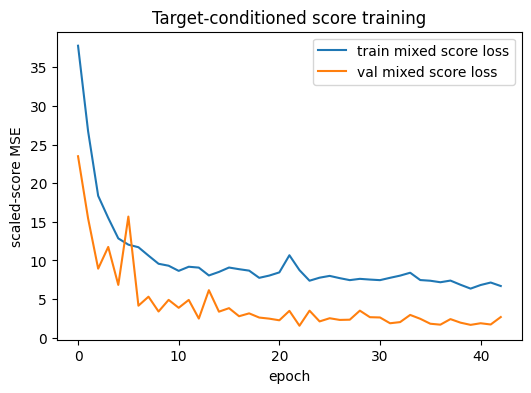

In [12]:
if "train_loss" in score_history and len(score_history["train_loss"]) > 0:
    fig = plt.figure(figsize=(6, 4))
    plt.plot(score_history["train_loss"], label="train mixed score loss")
    if "val_loss" in score_history:
        plt.plot(score_history["val_loss"], label="val mixed score loss")
    plt.xlabel("epoch")
    plt.ylabel("scaled-score MSE")
    plt.legend()
    plt.title("Target-conditioned score training")
    plt.show()
else:
    print("No training history found in checkpoint.")


## Latent-only student distillation

The target-grid model above is a strong reconstruction teacher.  This cell trains a latent-only student: the teacher receives the true target contour/grid, while the student receives only `z=f_phi(X)` and, if enabled, a generated latent raster decoded from `z`.  This is the bridge from target-conditioned reconstruction to real generation.

In [13]:
def current_student_model_config() -> dict[str, object]:
    cfg = dict(score_model_config)
    cfg.update({
        "use_target_grid_conditioning": STUDENT_USE_TARGET_GRID_CONDITIONING,
        "target_grid_feature_dim": TARGET_GRID_FEATURE_DIM,
        "target_grid_dropout_probability": STUDENT_TARGET_GRID_DROPOUT_PROBABILITY,
        "use_latent_raster_decoder": STUDENT_USE_LATENT_RASTER_DECODER,
        "use_measure_residual": STUDENT_USE_MEASURE_RESIDUAL,
        "measure_gate_init": STUDENT_MEASURE_GATE_INIT,
        "measure_gate_max": STUDENT_MEASURE_GATE_MAX,
    })
    return cfg


if RUN_LATENT_ONLY_STUDENT:
    student_model_config = current_student_model_config()
    latent_student_model = TargetConditionedScoreModel(**student_model_config).to(DEVICE)
    latent_student_history = train_latent_only_student_from_teacher(
        score_model,
        latent_student_model,
        train_pc.masses,
        train_pc.positions,
        train_pc.labels,
        val_masses=val_pc.masses,
        val_positions=val_pc.positions,
        val_labels=val_pc.labels,
        tau_levels=tau_levels,
        epochs=STUDENT_EPOCHS,
        batch_size=SCORE_BATCH_SIZE,
        lr=STUDENT_LR,
        weight_decay=STUDENT_WEIGHT_DECAY,
        query_modes=STUDENT_QUERY_MODES,
        direct_query_center_std=DIRECT_QUERY_CENTER_STD,
        latent_raster_loss_weight=STUDENT_RASTER_LOSS_WEIGHT,
        device=DEVICE,
        verbose=True,
    )
    generation_score_model = latent_student_model
    print("Using latent-only student for latent-prior generation.")
else:
    latent_student_model = None
    latent_student_history = {}
    generation_score_model = score_model
    print("Using the target-grid score model for latent-prior generation.")

latent_sensitivity = evaluate_latent_sensitivity(
    generation_score_model,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    tau_levels=tau_levels,
    max_samples=min(64, len(val_pc.labels)),
    batch_size=SCORE_BATCH_SIZE,
    query_mode="uniform",
    device=DEVICE,
)
pd.DataFrame([latent_sensitivity]).T.rename(columns={0: "value"})


[latent-student] epoch 0001/40: loss=81.7692 distill=81.5702 raster=0.198929 val=53.8627
[latent-student] epoch 0004/40: loss=43.9584 distill=43.8569 raster=0.101449 val=43.0274
[latent-student] epoch 0008/40: loss=40.921 distill=40.8509 raster=0.0700694 val=42.0435
[latent-student] epoch 0012/40: loss=38.3092 distill=38.2532 raster=0.0560294 val=40.5541
[latent-student] epoch 0016/40: loss=37.3747 distill=37.3307 raster=0.0439635 val=38.9247
[latent-student] epoch 0020/40: loss=41.1413 distill=41.0954 raster=0.0459554 val=40.0208
[latent-student] epoch 0024/40: loss=37.1201 distill=37.0765 raster=0.0435652 val=39.7431
[latent-student] epoch 0028/40: loss=38.2488 distill=38.2044 raster=0.0444509 val=39.471
[latent-student] epoch 0032/40: loss=38.0271 distill=37.9826 raster=0.0444637 val=39.8994
[latent-student] epoch 0036/40: loss=39.5996 distill=39.5524 raster=0.0472036 val=38.3578
[latent-student] epoch 0040/40: loss=38.0923 distill=38.0476 raster=0.0447143 val=35.9496
Using latent-o

,value
mean_scaled_score_norm,3.896579
wrong_latent_relative_change,0.000000
zero_latent_relative_change,0.200160
num_samples,64.000000


## One-step target-conditioned denoising diagnostic

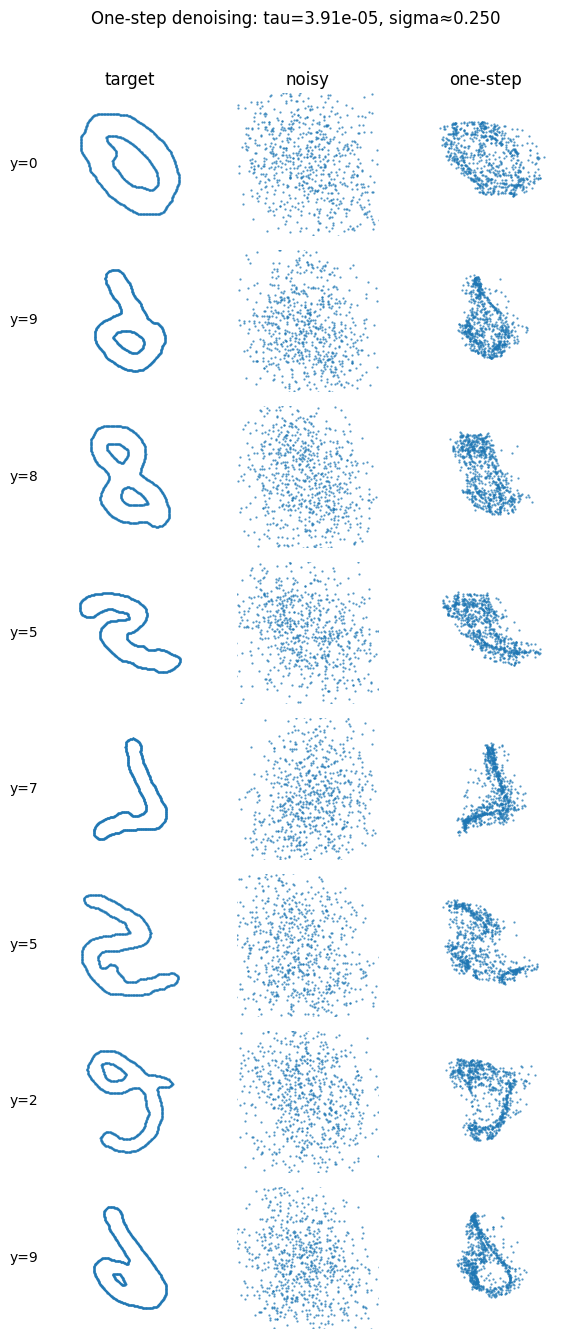

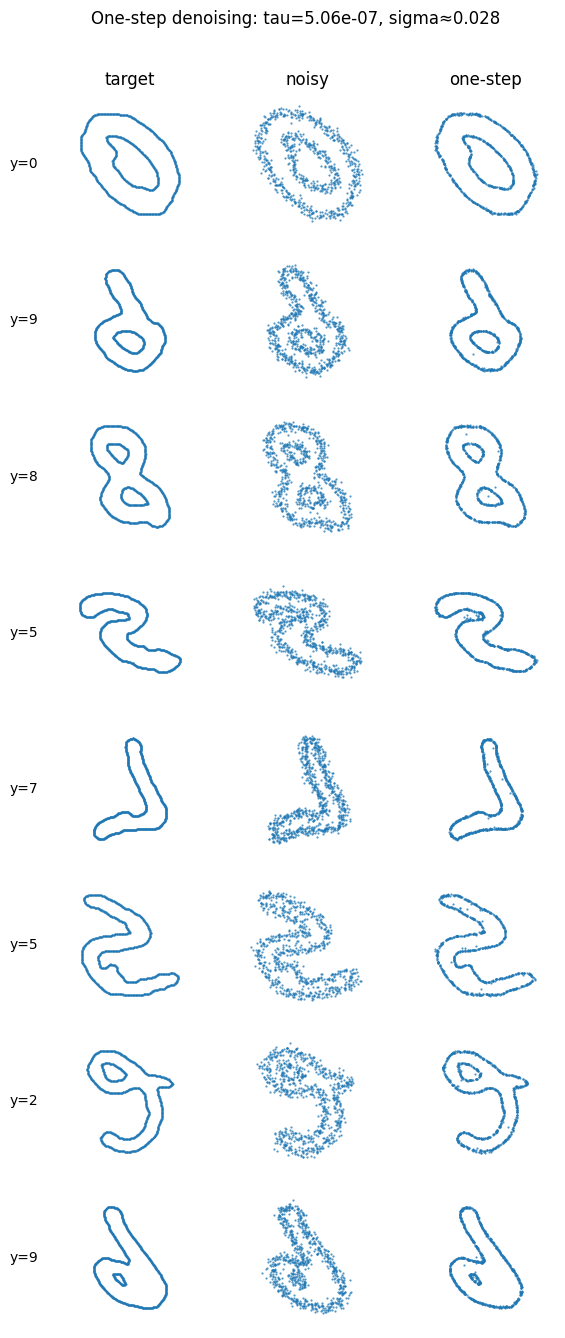

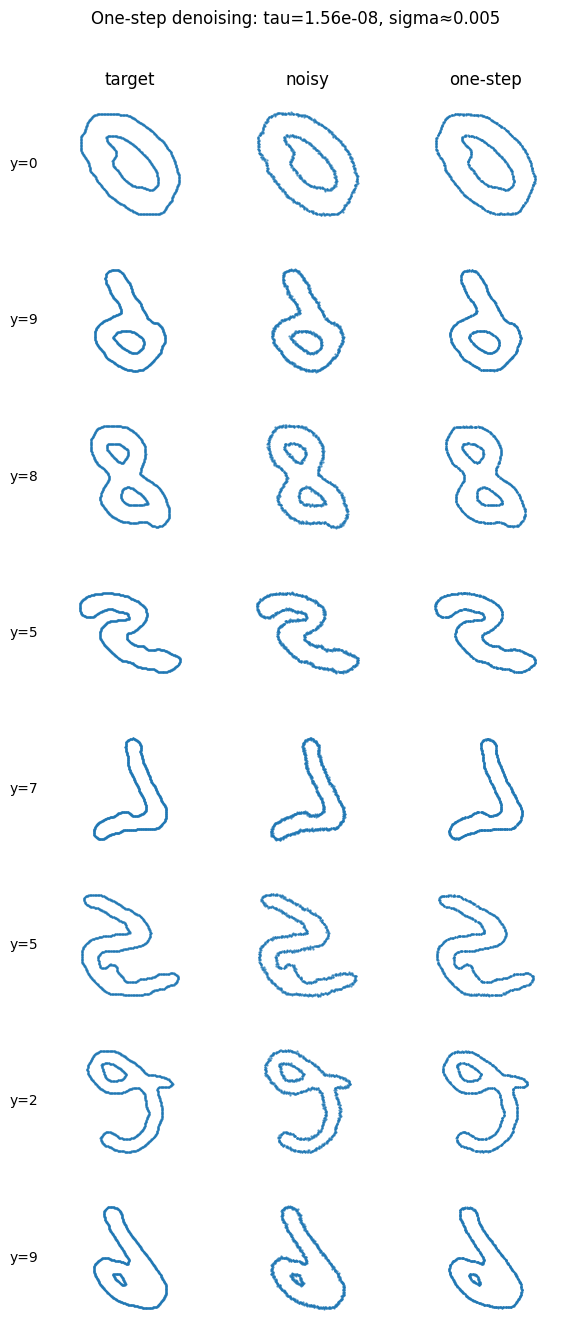

In [14]:
@torch.no_grad()
def one_step_target_denoising_samples(
    model: TargetConditionedScoreModel,
    masses_np: np.ndarray,
    positions_np: np.ndarray,
    labels_np: np.ndarray,
    *,
    tau_value: float,
    count: int = 32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    idx = np.arange(min(count, len(labels_np)))
    masses = torch.tensor(masses_np[idx], dtype=torch.float32, device=DEVICE)
    clean = torch.tensor(positions_np[idx], dtype=torch.float32, device=DEVICE)
    labels = torch.tensor(labels_np[idx], dtype=torch.long, device=DEVICE)
    tau = torch.full((len(idx),), float(tau_value), dtype=torch.float32, device=DEVICE)
    noisy, target_scaled, _ = perturb_target_conditioned_positions(masses, clean, tau, projection=DSM_PROJECTION)
    score = model(masses, noisy, tau, target_positions=clean, target_masses=masses, labels=labels)
    denoised = noisy + 2.0 * tau[:, None, None] * score
    return (
        clean.detach().cpu().numpy(),
        noisy.detach().cpu().numpy(),
        denoised.detach().cpu().numpy(),
        labels.detach().cpu().numpy(),
    )


def plot_one_step_triplets(clean, noisy, denoised, labels, *, examples: int = 8, title: str | None = None) -> None:
    n = min(examples, len(labels))
    fig, axes = plt.subplots(n, 3, figsize=(6.0, 1.65 * n), squeeze=False)
    for row in range(n):
        for col, (name, arr) in enumerate([("target", clean), ("noisy", noisy), ("one-step", denoised)]):
            ax = axes[row, col]
            pts = arr[row]
            ax.scatter(pts[:, 0], pts[:, 1], s=0.35 if pts.shape[0] > 300 else 1.0, alpha=0.75)
            ax.set_aspect("equal")
            ax.set_xlim(-0.20, 1.20)
            ax.set_ylim(1.20, -0.20)
            ax.axis("off")
            if row == 0:
                ax.set_title(name)
            if col == 0:
                ax.text(-0.35, 0.5, f"y={int(labels[row])}", transform=ax.transAxes, va="center")
    if title is not None:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()


# At the largest noise level the Bayes denoiser need not recover every contour in one step.
# The important diagnostic is that performance improves coherently as sigma decreases.
for tau_value in [tau_levels[0], tau_levels[len(tau_levels)//2], tau_levels[-1]]:
    clean, noisy, denoised, labels_used = one_step_target_denoising_samples(
        score_model,
        val_pc.masses,
        val_pc.positions,
        val_pc.labels,
        tau_value=float(tau_value),
        count=24,
    )
    sigma_unit = float(np.sqrt(2.0 * K * tau_value))
    plot_one_step_triplets(
        clean,
        noisy,
        denoised,
        labels_used,
        examples=8,
        title=f"One-step denoising: tau={tau_value:.2e}, sigma≈{sigma_unit:.3f}",
    )


## Oracle score diagnostics

These diagnostics separate sampler failure from score failure. The empirical Gaussian-mixture oracle is the exact ShapeGF-style contour field for a given target point cloud. If the oracle sampler works but the neural sampler collapses, the model is not matching the field on states visited by the sampler.

In [15]:
diagnostic_tau_levels = np.asarray([tau_levels[0], tau_levels[len(tau_levels)//2], tau_levels[-1]], dtype=np.float64)
oracle_diag_rows = evaluate_model_vs_mixture_oracle(
    score_model,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    tau_levels=diagnostic_tau_levels,
    query_modes=DIRECT_QUERY_MODES,
    max_samples=64 if not FAST_DEMO else 16,
    batch_size=SCORE_BATCH_SIZE,
    mixture_chunk_size=MIXTURE_CHUNK_SIZE,
    projection=DSM_PROJECTION,
    device=DEVICE,
)
oracle_diag_df = pd.DataFrame(oracle_diag_rows)
oracle_diag_df

,tau,sigma_approx,query_mode,physical_score_rmse,relative_rmse,cosine
0,3.906250e-05,0.250000,noised_target,0.753796,0.258503,0.966393
1,3.906250e-05,0.250000,uniform,0.745171,0.328299,0.944964
2,3.906250e-05,0.250000,center_gaussian,0.818003,0.266173,0.963926
3,5.058428e-07,0.028449,noised_target,5.443683,0.233895,0.978295
4,5.058428e-07,0.028449,uniform,24.636602,0.219483,0.976511
5,5.058428e-07,0.028449,center_gaussian,45.646332,0.244084,0.971908
6,1.562500e-08,0.005000,noised_target,69.576671,0.492571,0.885043
7,1.562500e-08,0.005000,uniform,848.981886,0.233033,0.973005
8,1.562500e-08,0.005000,center_gaussian,1439.131899,0.238903,0.973983


## Score calibration and hybrid diagnostics

Fit a scalar physical-score calibration and optional norm clipping for each sigma level by comparing the neural field against the exact empirical-mixture oracle. Then use hybrid oracle/neural reconstructions to identify which noise levels are causing collapse.

In [16]:
loaded_score_calibration = None
loaded_score_norm_clip = None
if globals().get("score_checkpoint_payload") is not None:
    loaded_score_calibration = score_checkpoint_payload.get("score_calibration")
    loaded_score_norm_clip = score_checkpoint_payload.get("score_norm_clip")

if USE_SCORE_CALIBRATION and loaded_score_calibration is not None:
    score_calibration = loaded_score_calibration
    score_norm_clip = loaded_score_norm_clip if USE_SCORE_CLIPPING else None
    print("Loaded score calibration from checkpoint.")
elif USE_SCORE_CALIBRATION:
    score_calibration = fit_score_calibration_against_mixture_oracle(
        score_model,
        val_pc.masses,
        val_pc.positions,
        val_pc.labels,
        tau_levels=tau_levels,
        query_modes=SCORE_CALIBRATION_QUERY_MODES,
        max_samples=SCORE_CALIBRATION_MAX_SAMPLES,
        batch_size=SCORE_BATCH_SIZE,
        mixture_chunk_size=MIXTURE_CHUNK_SIZE,
        projection=DSM_PROJECTION,
        clip_quantile=SCORE_CALIBRATION_CLIP_QUANTILE if USE_SCORE_CLIPPING else None,
        device=DEVICE,
    )
    score_norm_clip = score_calibration.physical_norm_clip if USE_SCORE_CLIPPING else None
else:
    score_calibration = None
    score_norm_clip = None
    calibration_df = None
    print("Skipping score calibration.")

if score_calibration is not None:
    clip_values = score_calibration.physical_norm_clip
    if clip_values is None:
        clip_values = np.full_like(score_calibration.tau_levels, np.nan, dtype=np.float64)
    calibration_df = pd.DataFrame({
        "level": np.arange(len(score_calibration.tau_levels)),
        "tau": score_calibration.tau_levels,
        "sigma_unit_square": np.sqrt(2.0 * K * score_calibration.tau_levels),
        "physical_score_scale": score_calibration.physical_score_scale,
        "physical_norm_clip": clip_values,
    })
    display(calibration_df)

# Refresh checkpoint after calibration so future runs can skip both training and calibration.
if SAVE_SCORE_CHECKPOINT:
    save_current_score_checkpoint("after_score_calibration")


# Separate calibration for latent-only generation if a student model is active.
if generation_score_model is score_model:
    generation_score_calibration = score_calibration
    generation_score_norm_clip = score_norm_clip
elif USE_SCORE_CALIBRATION:
    generation_score_calibration = fit_score_calibration_against_mixture_oracle(
        generation_score_model,
        val_pc.masses,
        val_pc.positions,
        val_pc.labels,
        tau_levels=tau_levels,
        query_modes=SCORE_CALIBRATION_QUERY_MODES,
        max_samples=SCORE_CALIBRATION_MAX_SAMPLES,
        batch_size=SCORE_BATCH_SIZE,
        mixture_chunk_size=MIXTURE_CHUNK_SIZE,
        projection=DSM_PROJECTION,
        clip_quantile=SCORE_CALIBRATION_CLIP_QUANTILE if USE_SCORE_CLIPPING else None,
        device=DEVICE,
    )
    generation_score_norm_clip = generation_score_calibration.physical_norm_clip if USE_SCORE_CLIPPING else None
else:
    generation_score_calibration = None
    generation_score_norm_clip = None


Loaded score calibration from checkpoint.


,level,tau,sigma_unit_square,physical_score_scale,physical_norm_clip
0,0,3.906250e-05,0.250000,0.982474,10.471761
1,1,1.637613e-05,0.161870,0.985848,22.003055
2,2,6.865343e-06,0.104807,0.997490,50.989837
3,3,2.878150e-06,0.067860,1.014925,120.667227
4,4,1.206603e-06,0.043938,1.037756,288.092462
5,5,5.058428e-07,0.028449,1.067852,683.878436
6,6,2.120639e-07,0.018420,1.090888,1627.155116
7,7,8.890328e-08,0.011927,1.080849,3900.376890
8,8,3.727082e-08,0.007722,1.058215,9330.755957
9,9,1.562500e-08,0.005000,1.074255,22367.106094


Saved score checkpoint [after_score_calibration] to /workspace/condition_df/artifacts/checkpoints/example_8b_mnist_cp_target_conditioned_score.pt


## Target-conditioned reconstruction from a simple prior

In [17]:
recon_idx = np.arange(min(RECONSTRUCTION_COUNT, len(val_pc.labels)))
reconstruction = reconstruct_target_conditioned_point_clouds(
    score_model,
    val_pc.masses[recon_idx],
    val_pc.positions[recon_idx],
    val_pc.labels[recon_idx],
    tau_levels=tau_levels,
    steps_per_level=STEPS_PER_LEVEL,
    sampler_scheme=SAMPLER_SCHEME,
    initial_position_mode="uniform",
    state_projection=STATE_PROJECTION,
    score_scale=SCORE_SCALE,
    diffusion_temperature=DIFFUSION_TEMPERATURE,
    final_polish_steps=FINAL_POLISH_STEPS,
    langevin_alpha=LANGEVIN_ALPHA,
    score_calibration=score_calibration,
    score_norm_clip=score_norm_clip,
    batch_size=SCORE_BATCH_SIZE,
    rasterize=False,
    return_trajectories=True,
    device=DEVICE,
    rng=np.random.default_rng(SEED + 10),
)
print(reconstruction.positions.shape)


(64, 800, 2)


,value
mean_chamfer,0.000046
median_chamfer,0.000036
std_chamfer,0.000039
squared_chamfer,True


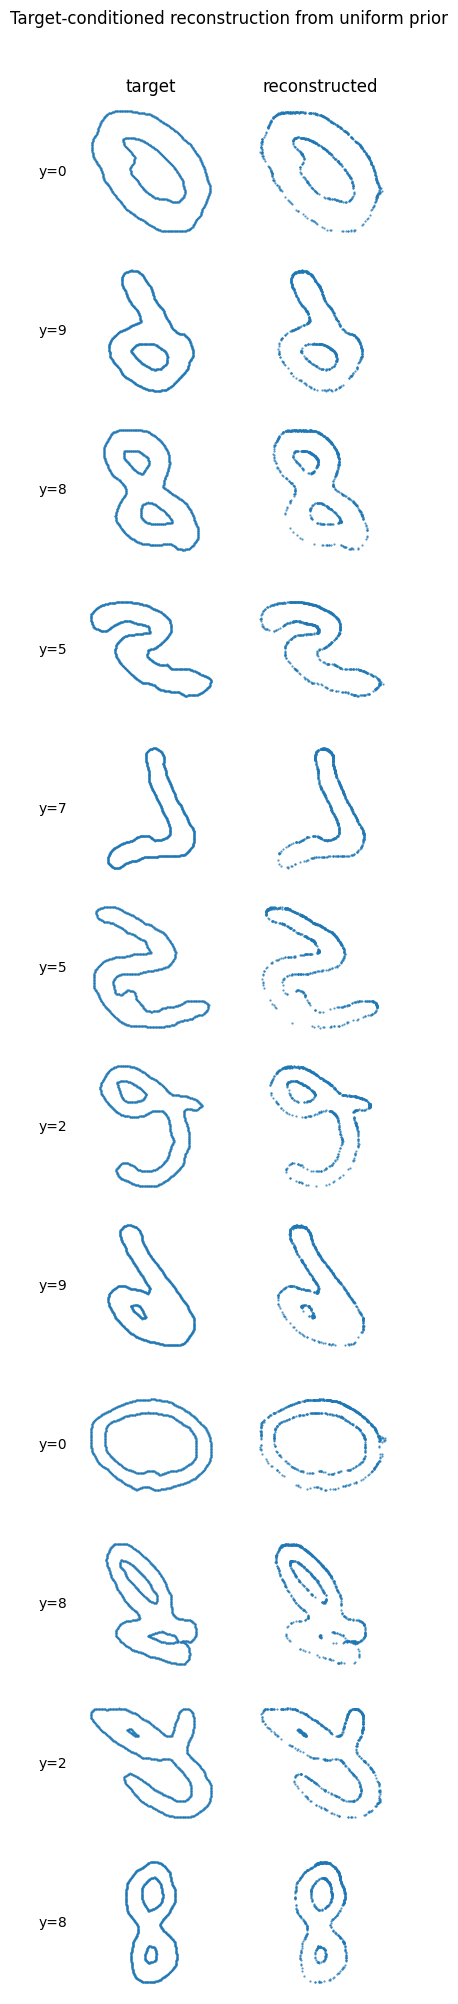

In [18]:
def plot_reconstruction_pairs(target_positions, generated_positions, labels, *, count: int = 10, title: str | None = None) -> None:
    n = min(count, len(labels))
    fig, axes = plt.subplots(n, 2, figsize=(4.0, 1.65 * n), squeeze=False)
    for row in range(n):
        for col, (name, arr) in enumerate([("target", target_positions), ("reconstructed", generated_positions)]):
            ax = axes[row, col]
            pts = arr[row]
            ax.scatter(pts[:, 0], pts[:, 1], s=0.35 if pts.shape[0] > 300 else 1.0, alpha=0.75)
            ax.set_aspect("equal")
            ax.set_xlim(-0.10, 1.10)
            ax.set_ylim(1.10, -0.10)
            ax.axis("off")
            if row == 0:
                ax.set_title(name)
            if col == 0:
                ax.text(-0.28, 0.5, f"y={int(labels[row])}", transform=ax.transAxes, va="center")
    if title is not None:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()


plot_reconstruction_pairs(
    val_pc.positions[recon_idx],
    reconstruction.positions,
    val_pc.labels[recon_idx],
    count=12,
    title="Target-conditioned reconstruction from uniform prior",
)

recon_metrics = paired_chamfer_reconstruction_metrics(
    reconstruction.positions,
    val_pc.positions[recon_idx],
    val_pc.labels[recon_idx],
    squared=True,
)
recon_summary = {k: v for k, v in recon_metrics.items() if k not in {"per_sample_chamfer", "per_label"}}
pd.DataFrame([recon_summary]).T.rename(columns={0: "value"})


,value
mean_chamfer,0.000008
median_chamfer,0.000007
std_chamfer,0.000002
squared_chamfer,True


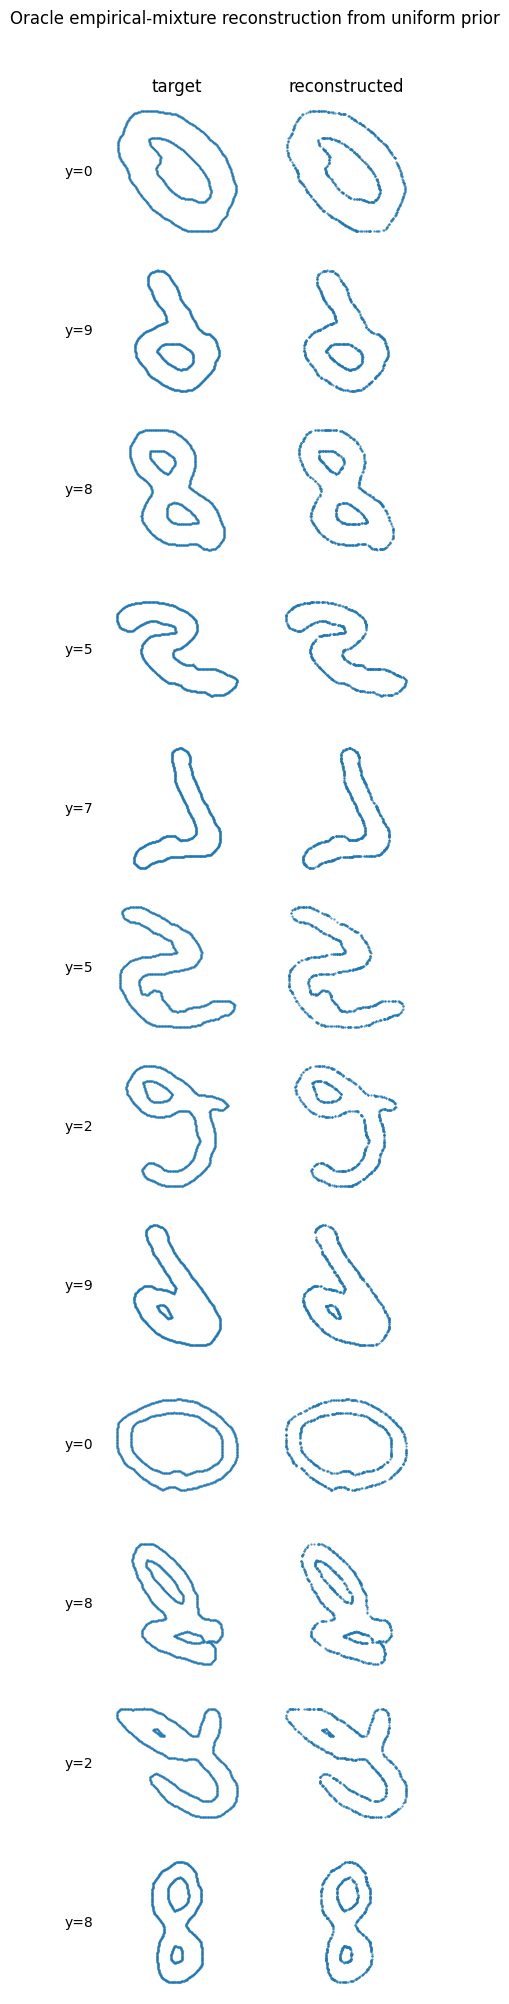

In [19]:

# Oracle reconstruction: same sampler, but with the exact empirical mixture score instead of the neural score.
# If this looks good and the neural reconstruction does not, improve training/model before touching the latent prior.
oracle_reconstruction = sample_oracle_mixture_annealed_dynamics(
    target_masses=val_pc.masses[recon_idx],
    target_positions=val_pc.positions[recon_idx],
    labels=val_pc.labels[recon_idx],
    tau_levels=tau_levels,
    steps_per_level=STEPS_PER_LEVEL,
    initial_position_mode="uniform",
    state_projection=STATE_PROJECTION,
    score_scale=SCORE_SCALE,
    diffusion_temperature=DIFFUSION_TEMPERATURE,
    final_polish_steps=FINAL_POLISH_STEPS,
    langevin_alpha=LANGEVIN_ALPHA,
    batch_size=SCORE_BATCH_SIZE,
    rasterize=False,
    return_trajectories=False,
    device=DEVICE,
    rng=np.random.default_rng(SEED + 11),
)
plot_reconstruction_pairs(
    val_pc.positions[recon_idx],
    oracle_reconstruction.positions,
    val_pc.labels[recon_idx],
    count=12,
    title="Oracle empirical-mixture reconstruction from uniform prior",
)
oracle_recon_metrics = paired_chamfer_reconstruction_metrics(
    oracle_reconstruction.positions,
    val_pc.positions[recon_idx],
    val_pc.labels[recon_idx],
    squared=True,
)
pd.DataFrame([{k: v for k, v in oracle_recon_metrics.items() if k not in {"per_sample_chamfer", "per_label"}}]).T.rename(columns={0: "value"})

## Hybrid oracle/neural reconstruction bisection

These rows answer: how many early high-noise levels need the oracle before the neural field can finish the reconstruction? If `oracle_levels=1` or `2` fixes collapse, the high-sigma global field is the bottleneck; if only full oracle works, mid/fine off-trajectory fields are still unreliable.

In [20]:

if RUN_HYBRID_BISECTION_DIAGNOSTIC:
    hybrid_rows = evaluate_hybrid_oracle_neural_reconstruction(
        score_model,
        val_pc.masses[recon_idx],
        val_pc.positions[recon_idx],
        val_pc.labels[recon_idx],
        tau_levels=tau_levels,
        prefix_levels=HYBRID_PREFIX_LEVELS,
        suffix_levels=HYBRID_SUFFIX_LEVELS,
        max_samples=HYBRID_BISECTION_MAX_SAMPLES,
        steps_per_level=STEPS_PER_LEVEL,
        sampler_scheme=SAMPLER_SCHEME,
        initial_position_mode="uniform",
        state_projection=STATE_PROJECTION,
        score_scale=SCORE_SCALE,
        diffusion_temperature=DIFFUSION_TEMPERATURE,
        langevin_alpha=LANGEVIN_ALPHA,
        score_calibration=score_calibration,
        score_norm_clip=score_norm_clip,
        batch_size=SCORE_BATCH_SIZE,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 12),
    )
    hybrid_df = pd.DataFrame(hybrid_rows)
    display(hybrid_df)
else:
    hybrid_df = None
    print("Skipping hybrid oracle/neural bisection diagnostic.")


,mode,oracle_levels,mean_chamfer,median_chamfer,std_chamfer,num_samples
0,oracle_prefix,0,0.000047,0.000040,0.000036,24
1,oracle_prefix,1,0.000053,0.000037,0.000045,24
2,oracle_prefix,2,0.000058,0.000032,0.000104,24
3,oracle_prefix,3,0.000041,0.000033,0.000032,24
4,oracle_prefix,5,0.000021,0.000020,0.000008,24
5,oracle_prefix,10,0.000008,0.000009,0.000002,24


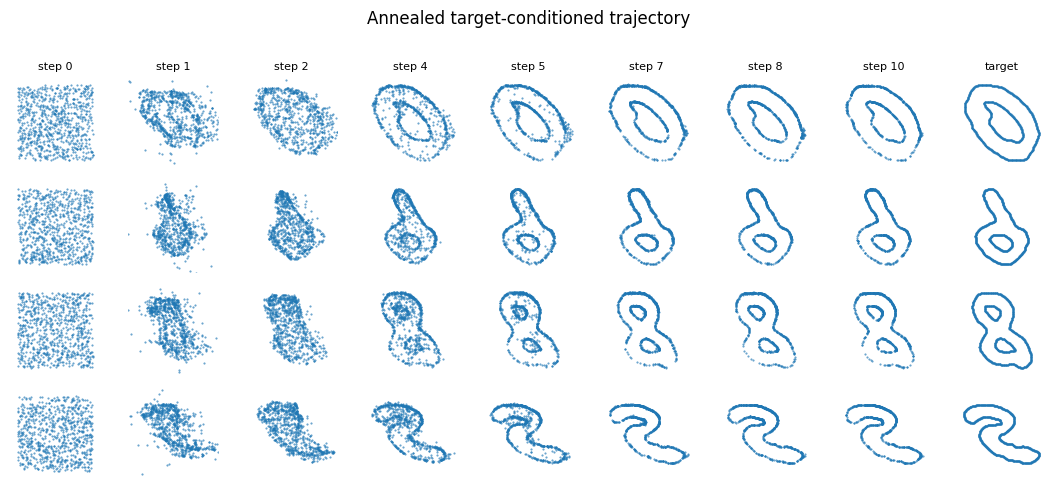

In [21]:

# Optional trajectory visualization for the first few reconstructions.
if reconstruction.trajectories is not None:
    traj = reconstruction.trajectories
    chosen_times = np.linspace(0, traj.shape[0] - 1, min(8, traj.shape[0]), dtype=int)
    rows = min(4, traj.shape[1])
    fig, axes = plt.subplots(rows, len(chosen_times) + 1, figsize=(1.2 * (len(chosen_times) + 1), 1.2 * rows), squeeze=False)
    for row in range(rows):
        for col, t_idx in enumerate(chosen_times):
            ax = axes[row, col]
            pts = traj[t_idx, row]
            ax.scatter(pts[:, 0], pts[:, 1], s=0.25 if pts.shape[0] > 300 else 0.8, alpha=0.75)
            ax.set_aspect("equal")
            ax.set_xlim(-0.10, 1.10)
            ax.set_ylim(1.10, -0.10)
            ax.axis("off")
            if row == 0:
                ax.set_title(f"step {t_idx}", fontsize=8)
        ax = axes[row, -1]
        pts = val_pc.positions[recon_idx[row]]
        ax.scatter(pts[:, 0], pts[:, 1], s=0.25 if pts.shape[0] > 300 else 0.8, alpha=0.75)
        ax.set_aspect("equal")
        ax.set_xlim(-0.10, 1.10)
        ax.set_ylim(1.10, -0.10)
        ax.axis("off")
        if row == 0:
            ax.set_title("target", fontsize=8)
    fig.suptitle("Annealed target-conditioned trajectory", y=1.01)
    plt.tight_layout()


## Latent-prior diagnostics and generation baselines

The target-conditioned reconstruction above passes the actual target contour to the model. Generation does not have a target contour, only a sampled latent terminal code. These diagnostics separate three questions:

1. Can the sampler reconstruct from a real encoded validation latent `z` without target-grid features?
2. Does sampling actual encoded training latents work?
3. Which simple latent prior stays close enough to the encoded latent manifold?

In [22]:

checkpoint_extra = {}
if globals().get("score_checkpoint_payload") is not None:
    checkpoint_extra = score_checkpoint_payload.get("extra", {}) or {}

if "train_latents" in checkpoint_extra and "val_latents" in checkpoint_extra:
    train_latents = np.asarray(checkpoint_extra["train_latents"], dtype=np.float64)
    val_latents = np.asarray(checkpoint_extra["val_latents"], dtype=np.float64)
    print("Loaded train/val latents from checkpoint.")
else:
    train_latents = encode_target_latents(
        generation_score_model,
        train_pc.masses,
        train_pc.positions,
        batch_size=SCORE_BATCH_SIZE,
        device=DEVICE,
    )
    val_latents = encode_target_latents(
        generation_score_model,
        val_pc.masses,
        val_pc.positions,
        batch_size=SCORE_BATCH_SIZE,
        device=DEVICE,
    )
print("train latents:", train_latents.shape, "val latents:", val_latents.shape)

latent_prior = fit_gaussian_latent_prior(
    train_latents,
    train_pc.labels,
    diagonal=GAUSSIAN_LATENT_DIAGONAL,
    eps=1e-4,
)
pca_latent_prior = fit_pca_latent_prior(
    train_latents,
    train_pc.labels,
    pca_dim=PCA_LATENT_DIM,
    shrink=PCA_LATENT_SHRINK,
    eps=1e-4,
    layernorm_project=PCA_LATENT_LAYERNORM_PROJECT,
)
pca_gmm_latent_prior = fit_pca_gmm_latent_prior(
    train_latents,
    train_pc.labels,
    pca_dim=PCA_LATENT_DIM,
    components_per_class=PCA_GMM_COMPONENTS_PER_CLASS,
    covariance_shrink=PCA_GMM_COVARIANCE_SHRINK,
    eps=1e-4,
    max_iter=50,
    layernorm_project=PCA_GMM_LAYERNORM_PROJECT,
    rng=np.random.default_rng(SEED + 40),
)
print("Gaussian prior components:", latent_prior.num_components, "latent_dim:", latent_prior.latent_dim)
print("PCA prior components:", pca_latent_prior.num_components, "pca_dim:", pca_latent_prior.pca_dim)
print("PCA-GMM components per class:", pca_gmm_latent_prior.components_per_class)


def balanced_labels(num_per_class: int, *, num_classes: int = 10) -> np.ndarray:
    return np.repeat(np.arange(num_classes, dtype=np.int64), int(num_per_class))


def generation_chamfer_metrics(
    generated: GeneratedPointCloudSet,
    reference_positions: np.ndarray,
    reference_labels: np.ndarray,
    *,
    max_per_class: int = 32,
    seed: int = 0,
) -> dict[str, object]:
    rng = np.random.default_rng(seed)
    per_label = {}
    one_nn_values = []
    coverage_values = []
    mmd_values = []
    for label in np.unique(generated.labels):
        gen_idx = np.flatnonzero(generated.labels == label)
        ref_idx = np.flatnonzero(reference_labels == label)
        if len(gen_idx) == 0 or len(ref_idx) == 0:
            continue
        gen_idx = rng.choice(gen_idx, size=min(max_per_class, len(gen_idx)), replace=False)
        ref_idx = rng.choice(ref_idx, size=min(max_per_class, len(ref_idx)), replace=False)
        gen_x = generated.positions[gen_idx]
        ref_x = reference_positions[ref_idx]
        rg = pairwise_chamfer_distance_matrix(ref_x, gen_x, squared=True)
        one_nn = one_nn_leave_one_out_chamfer(ref_x, gen_x, squared=True)
        cov = coverage_unique_argmin_chamfer(ref_x, gen_x, squared=True)
        mmd = float(np.mean(np.min(rg, axis=1)))
        per_label[int(label)] = {
            "mmd_cd": mmd,
            "coverage_cd": float(cov["coverage"]),
            "one_nn_cd_accuracy": float(one_nn["accuracy"]),
        }
        mmd_values.append(mmd)
        coverage_values.append(float(cov["coverage"]))
        one_nn_values.append(float(one_nn["accuracy"]))
    return {
        "mmd_cd_macro": float(np.mean(mmd_values)) if mmd_values else float("nan"),
        "coverage_cd_macro": float(np.mean(coverage_values)) if coverage_values else float("nan"),
        "one_nn_cd_accuracy_macro": float(np.mean(one_nn_values)) if one_nn_values else float("nan"),
        "per_label": per_label,
    }


# The test split is already named `reference_pc` in the data-loading cell.
# Do not refer to an undefined `test_pc` here.


def sample_with_latents(
    name: str,
    z: np.ndarray,
    y: np.ndarray,
    *,
    seed: int,
) -> tuple[GeneratedPointCloudSet, dict[str, object]]:
    generated = sample_target_conditioned_annealed_dynamics(
        generation_score_model,
        target_latents=z,
        labels=y,
        num_points=K,
        tau_levels=tau_levels,
        steps_per_level=STEPS_PER_LEVEL,
        sampler_scheme=SAMPLER_SCHEME,
        initial_position_mode="uniform",
        state_projection=STATE_PROJECTION,
        score_scale=SCORE_SCALE,
        diffusion_temperature=DIFFUSION_TEMPERATURE,
        final_polish_steps=FINAL_POLISH_STEPS,
        langevin_alpha=LANGEVIN_ALPHA,
        score_calibration=generation_score_calibration,
        score_norm_clip=generation_score_norm_clip,
        batch_size=SCORE_BATCH_SIZE,
        rasterize=False,
        device=DEVICE,
        rng=np.random.default_rng(seed),
    )
    metrics = generation_chamfer_metrics(
        generated,
        reference_pc.positions,
        reference_pc.labels,
        max_per_class=min(32, LATENT_PRIOR_DIAGNOSTIC_PER_CLASS),
        seed=seed + 1,
    )
    metrics = {"prior": name, **{k: v for k, v in metrics.items() if k != "per_label"}}
    return generated, metrics


# Save encoded latents and fitted latent-prior objects for faster reruns of the diagnostic section.
if SAVE_SCORE_CHECKPOINT:
    save_current_score_checkpoint("after_latent_prior_fit")


train latents: (20000, 128) val latents: (2500, 128)
Gaussian prior components: 10 latent_dim: 128
PCA prior components: 10 pca_dim: 32
PCA-GMM components per class: 8
Saved score checkpoint [after_latent_prior_fit] to /workspace/condition_df/artifacts/checkpoints/example_8b_mnist_cp_target_conditioned_score.pt


### Real-`z` latent-only reconstruction

This cell intentionally does **not** pass `target_positions` to the sampler. If this fails while the target-grid reconstruction works, generation will also fail because the latent prior only supplies `z`.

,value
mean_chamfer,0.012698
median_chamfer,0.011363
std_chamfer,0.007443
squared_chamfer,True


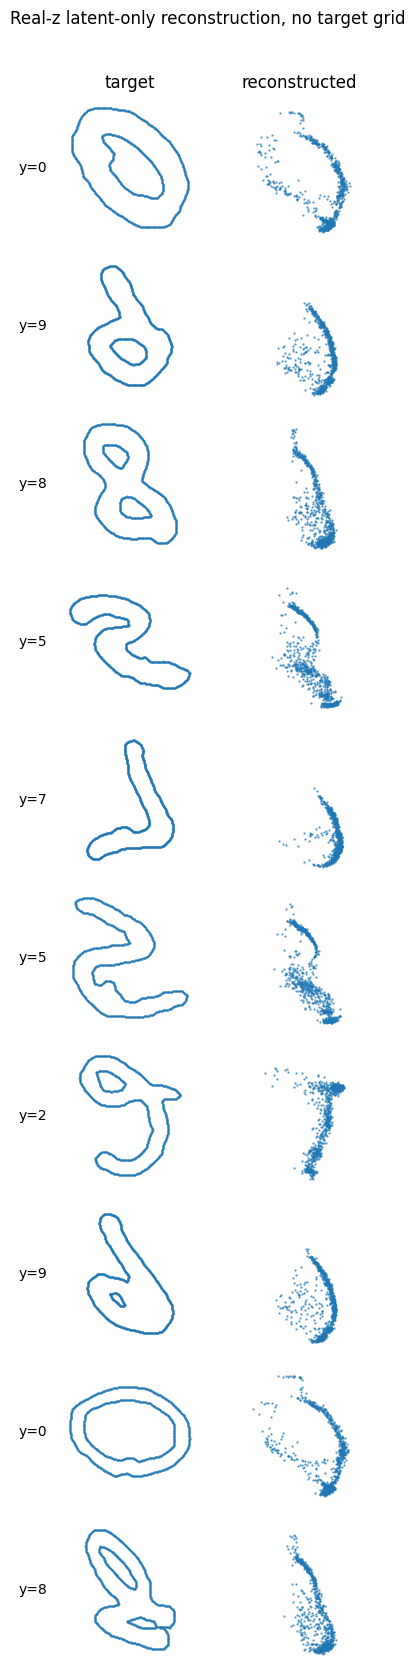

In [23]:

if RUN_LATENT_ONLY_RECONSTRUCTION:
    latent_only_z = val_latents[recon_idx]
    latent_only_y = val_pc.labels[recon_idx]
    latent_only_reconstruction = reconstruct_target_conditioned_from_latents(
        generation_score_model,
        latent_only_z,
        labels=latent_only_y,
        output_masses=val_pc.masses[recon_idx],
        tau_levels=tau_levels,
        steps_per_level=STEPS_PER_LEVEL,
        sampler_scheme=SAMPLER_SCHEME,
        initial_position_mode="uniform",
        state_projection=STATE_PROJECTION,
        score_scale=SCORE_SCALE,
        diffusion_temperature=DIFFUSION_TEMPERATURE,
        final_polish_steps=FINAL_POLISH_STEPS,
        langevin_alpha=LANGEVIN_ALPHA,
        score_calibration=generation_score_calibration,
        score_norm_clip=generation_score_norm_clip,
        batch_size=SCORE_BATCH_SIZE,
        rasterize=False,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 41),
    )
    latent_only_recon_metrics = paired_chamfer_reconstruction_metrics(
        latent_only_reconstruction.positions,
        val_pc.positions[recon_idx],
        latent_only_y,
        squared=True,
    )
    plot_reconstruction_pairs(
        val_pc.positions[recon_idx],
        latent_only_reconstruction.positions,
        latent_only_y,
        count=10,
        title="Real-z latent-only reconstruction, no target grid",
    )
    display(pd.DataFrame([{k: v for k, v in latent_only_recon_metrics.items() if k not in {"per_sample_chamfer", "per_label"}}]).T.rename(columns={0: "value"}))
else:
    latent_only_reconstruction = None
    latent_only_recon_metrics = None


### Latent nearest-neighbor diagnostics

For each prior, compare sampled latent codes to the encoded training latent bank. If a prior has much larger nearest-neighbor distance than validation latents, it is likely sampling off the learned terminal-code manifold.

In [24]:

gen_labels = balanced_labels(LATENT_PRIOR_DIAGNOSTIC_PER_CLASS)
latent_prior_samples: dict[str, tuple[np.ndarray, np.ndarray]] = {}

# Baseline: actual encoded training latents. This should work before any smooth parametric prior.
if RUN_EMPIRICAL_LATENT_PRIOR:
    empirical_z, empirical_y = sample_empirical_latent_prior(
        train_latents,
        train_pc.labels,
        requested_labels=gen_labels,
        noise_scale=0.0,
        layernorm_project=False,
        rng=np.random.default_rng(SEED + 42),
    )
    latent_prior_samples["empirical_train_z"] = (empirical_z, empirical_y)

    for noise_scale in EMPIRICAL_LATENT_NOISE_SCALES:
        if noise_scale <= 0.0:
            continue
        z_noise, y_noise = sample_empirical_latent_prior(
            train_latents,
            train_pc.labels,
            requested_labels=gen_labels,
            noise_scale=float(noise_scale),
            layernorm_project=EMPIRICAL_LATENT_LAYERNORM_PROJECT,
            rng=np.random.default_rng(SEED + int(1000 * noise_scale) + 43),
        )
        latent_prior_samples[f"empirical_z_noise_{noise_scale:.2f}"] = (z_noise, y_noise)

# Raw/shrunk Gaussian baseline.
gaussian_z, gaussian_y = sample_gaussian_latent_prior(
    latent_prior,
    labels=gen_labels,
    covariance_scale=GAUSSIAN_LATENT_COVARIANCE_SCALE,
    layernorm_project=GAUSSIAN_LATENT_LAYERNORM_PROJECT,
    rng=np.random.default_rng(SEED + 44),
)
latent_prior_samples[f"gaussian_scale_{GAUSSIAN_LATENT_COVARIANCE_SCALE:.2f}"] = (gaussian_z, gaussian_y)

if RUN_PCA_LATENT_PRIORS:
    pca_z, pca_y = sample_pca_latent_prior(
        pca_latent_prior,
        labels=gen_labels,
        shrink=PCA_LATENT_SHRINK,
        layernorm_project=PCA_LATENT_LAYERNORM_PROJECT,
        rng=np.random.default_rng(SEED + 45),
    )
    latent_prior_samples[f"pca_shrink_{PCA_LATENT_SHRINK:.2f}"] = (pca_z, pca_y)

    pca_gmm_z, pca_gmm_y = sample_pca_gmm_latent_prior(
        pca_gmm_latent_prior,
        labels=gen_labels,
        covariance_shrink=PCA_GMM_COVARIANCE_SHRINK,
        layernorm_project=PCA_GMM_LAYERNORM_PROJECT,
        rng=np.random.default_rng(SEED + 46),
    )
    latent_prior_samples[f"pca_gmm_shrink_{PCA_GMM_COVARIANCE_SHRINK:.2f}"] = (pca_gmm_z, pca_gmm_y)

nn_rows = []
val_nn_idx = np.arange(min(LATENT_NN_DIAGNOSTIC_MAX_SAMPLES, len(val_latents)))
validation_summary = latent_nearest_neighbor_summary(
    val_latents[val_nn_idx],
    train_latents,
    query_labels=val_pc.labels[val_nn_idx],
    reference_labels=train_pc.labels,
    same_label=True,
    max_reference=min(2000, len(train_latents)),
    rng=np.random.default_rng(SEED + 47),
)
nn_rows.append({"prior": "validation_encoded_z", **{k: v for k, v in validation_summary.items() if k not in {"nearest_indices", "per_label"}}})
for name, (z, y) in latent_prior_samples.items():
    summary = latent_nearest_neighbor_summary(
        z,
        train_latents,
        query_labels=y,
        reference_labels=train_pc.labels,
        same_label=True,
        max_reference=min(2000, len(train_latents)),
        rng=np.random.default_rng(SEED + 48),
    )
    nn_rows.append({"prior": name, **{k: v for k, v in summary.items() if k not in {"nearest_indices", "per_label"}}})
latent_nn_df = pd.DataFrame(nn_rows).set_index("prior")
latent_nn_df


,num_queries,mean_nn_distance,median_nn_distance,q90_nn_distance,q95_nn_distance,p95_nn_distance,max_nn_distance,mean,median,q95,same_label
prior,,,,,,,,,,,
validation_encoded_z,256,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,True
empirical_train_z,160,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,True
empirical_z_noise_0.01,160,1.133407e-13,1.136464e-13,1.209101e-13,1.234349e-13,1.234349e-13,1.289548e-13,1.133407e-13,1.136464e-13,1.234349e-13,True
empirical_z_noise_0.03,160,3.380851e-13,3.396385e-13,3.644922e-13,3.719131e-13,3.719131e-13,3.918196e-13,3.380851e-13,3.396385e-13,3.719131e-13,True
empirical_z_noise_0.05,160,5.667452e-13,5.641732e-13,6.152519e-13,6.224983e-13,6.224983e-13,6.520956e-13,5.667452e-13,5.641732e-13,6.224983e-13,True
gaussian_scale_0.25,160,3.970700e+00,3.970696e+00,3.970807e+00,3.970838e+00,3.970838e+00,3.970943e+00,3.970700e+00,3.970696e+00,3.970838e+00,True
pca_shrink_0.50,160,3.970390e+00,3.970385e+00,3.970485e+00,3.970519e+00,3.970519e+00,3.970571e+00,3.970390e+00,3.970385e+00,3.970519e+00,True
pca_gmm_shrink_0.50,160,3.970397e+00,3.970389e+00,3.970491e+00,3.970518e+00,3.970518e+00,3.970619e+00,3.970397e+00,3.970389e+00,3.970518e+00,True


### Generate from latent-prior candidates

Read these in order: empirical train latents first, then empirical + tiny noise, then PCA/PCA-GMM, then the Gaussian baseline. If empirical latents work but Gaussian does not, the score/dynamics stage is fine and the problem is just the terminal-code prior.

In [ ]:
generated_by_prior: dict[str, GeneratedPointCloudSet] = {}
generation_rows = []
for offset, (name, (z, y)) in enumerate(latent_prior_samples.items()):
    generated, metrics = sample_with_latents(name, z, y, seed=SEED + 50 + offset)
    generated_by_prior[name] = generated
    generation_rows.append(metrics)
    plot_mnist_cp_gallery(
        generated.positions,
        generated.labels,
        examples_per_label=min(5, LATENT_PRIOR_DIAGNOSTIC_PER_CLASS),
        title=f"Generated MNIST-CP contours from {name}",
        seed=SEED + 70 + offset,
    )
latent_generation_df = pd.DataFrame(generation_rows).set_index("prior")
latent_generation_df

## Optional latent prior: WGAN-GP over encoded `z`

Keep this disabled until real-`z` latent-only reconstruction and empirical/PCA-prior generation are good. ShapeGF uses a second-stage latent GAN after training the gradient-field autoencoder; here the same idea is optional because the theory-focused object is the target-conditioned Wasserstein score/dynamics stage.

In [ ]:
if RUN_LATENT_WGAN:
    latent_generator = LatentGenerator(
        noise_dim=LATENT_NOISE_DIM,
        latent_dim=Z_DIM,
        hidden_dims=(256, 256),
        conditional=True,
        num_classes=10,
        label_embedding_dim=32,
        noise_std=0.2,
    )
    latent_critic = LatentCritic(
        latent_dim=Z_DIM,
        hidden_dims=(512, 512),
        conditional=True,
        num_classes=10,
        label_embedding_dim=32,
    )
    latent_wgan_history = train_latent_wgan_gp(
        latent_generator,
        latent_critic,
        train_latents,
        train_pc.labels,
        epochs=LATENT_WGAN_EPOCHS,
        batch_size=LATENT_WGAN_BATCH_SIZE,
        lr=LATENT_WGAN_LR,
        gradient_penalty_weight=LATENT_WGAN_GP,
        critic_steps=LATENT_WGAN_CRITIC_STEPS,
        device=DEVICE,
        verbose=True,
    )
else:
    latent_generator = None
    latent_critic = None
    latent_wgan_history = None
    print("Skipping latent WGAN. Set RUN_LATENT_WGAN=True to train it.")


In [ ]:
if latent_wgan_history is not None:
    fig = plt.figure(figsize=(6, 4))
    plt.plot(latent_wgan_history["critic_loss"], label="critic")
    plt.plot(latent_wgan_history["generator_loss"], label="generator")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Latent WGAN-GP training")
    plt.legend()
    plt.show()

if latent_generator is not None:
    wgan_z, wgan_y = sample_wgan_latent_prior(
        latent_generator,
        labels=gen_labels,
        device=DEVICE,
    )
    wgan_generated, wgan_metrics = sample_with_latents("wgan_latent_prior", wgan_z, wgan_y, seed=SEED + 90)
    plot_mnist_cp_gallery(
        wgan_generated.positions,
        wgan_generated.labels,
        examples_per_label=min(5, LATENT_PRIOR_DIAGNOSTIC_PER_CLASS),
        title="Generated MNIST-CP contours from WGAN latent prior",
        seed=SEED + 91,
    )
    display(pd.DataFrame([wgan_metrics]).set_index("prior"))
else:
    wgan_generated = None
    wgan_metrics = None


## Suggested ablations

The most useful debugging sequence is:

- Compare target-grid reconstruction against real-`z` latent-only reconstruction. If the former works but the latter fails, increase `TARGET_GRID_DROPOUT_PROBABILITY` and/or train a latent-only version.
- Try `empirical_train_z` before Gaussian or WGAN. If empirical-z generation works, the Wasserstein score/dynamics stage is good and the remaining problem is the terminal-code prior.
- Prefer empirical-z with tiny noise, `pca_shrink_*`, or `pca_gmm_shrink_*` over a raw diagonal Gaussian. The encoder latent distribution is usually correlated and shell-like.
- Only turn `RUN_LATENT_WGAN=True` after real-z latent-only reconstruction and empirical/PCA-prior generation are visually acceptable.

For reporting, prioritize paired reconstruction CD for the autoencoding stage and MMD/COV/1-NNA Chamfer for latent-prior generation. Classifier accuracy is less central here than contour geometry.